In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize, CenteredNorm
from matplotlib.patches import Circle
import astropy.units as u
from astropy.io import fits
import os
from pathlib import Path
import time
import copy
from IPython.display import clear_output
from datetime import datetime
today = int(datetime.today().strftime('%Y%m%d'))

import poppy
from poppy.poppy_core import PlaneType

import logging, sys
poppy_log = logging.getLogger('poppy')
poppy_log.setLevel('DEBUG')
logging.basicConfig(stream=sys.stdout, level=logging.INFO)
poppy_log.disabled = True

from importlib import reload

import esc_fresnel

import esc_fresnel.utils as utils
from esc_fresnel.math_module import xp, xcipy, ensure_np_array
from esc_fresnel.imshows import imshow1, imshow2, imshow3, imshow
import esc_fresnel.esc_fresnel as esc
import esc_fresnel.esc_optics as esc_optics

dm_flat = utils.load_fits(esc_fresnel.path/'dm-commands/esc_fresnel_dm_flat.fits')
# dh_command = utils.load_fits('../data/esc_fresnel_dm_dh_command_1e-8.fits')
# dh_command = utils.load_fits('../data/esc_fresnel_dm_dh_command_1e-9.fits')
dh_command = utils.load_fits(esc_fresnel.path/'dm-commands/esc_fresnel_dm_dh_command_6e-10.fits')



In [3]:
amp_dir = '/home/kianmilani/Projects/esc-fresnel/esc_fresnel/wfe-maps/reflectivity_maps_2024_09_15/'
opd_dir = '/home/kianmilani/Projects/esc-fresnel/esc_fresnel/wfe-maps/6nm_surfPSD/'

wfe_optic = 12

# Ignore OAP7 So that doesn't add any WFE when we compute the flat
opd_rms_vals = {
    'm1': 2*21*u.nm, 
    'm2': 2*8*u.nm, 
    'm3': 2*6*u.nm, 
    'm4': 2*12*u.nm, 
    'oap1': wfe_optic*u.nm,
    'fm1': wfe_optic*u.nm, 
    'oap2': wfe_optic*u.nm, 
    'oap3': wfe_optic*u.nm, 
    'fsm': wfe_optic*u.nm, 
    'fm2': wfe_optic*u.nm, 
    'oap4': wfe_optic*u.nm, 
    'oap5': wfe_optic*u.nm, 
    'input_lp': wfe_optic*u.nm, 
    'input_qwp': wfe_optic*u.nm, 
    'oap6': wfe_optic*u.nm, 
    'oap7': wfe_optic*u.nm, 
    'oap9': wfe_optic*u.nm, 
    'collimator': wfe_optic*u.nm, 
    'filter': wfe_optic*u.nm, 
    'output_qwp': wfe_optic*u.nm,
    'output_lp': wfe_optic*u.nm, 
    'oap10': wfe_optic*u.nm, 
}

wfes = {}
for optic in opd_rms_vals.keys():
    wfe = poppy.FITSOpticalElement(
        opd=opd_dir + f'{optic}_subap.fits', 
        opdunits='nanometers',
        transmission=amp_dir + f'{optic}_amp_subap_1000px.fits',
        name=f'{optic}_wfe',
        planetype=poppy.poppy_core.PlaneType.intermediate,
    )
    wfes[optic] = wfe

0


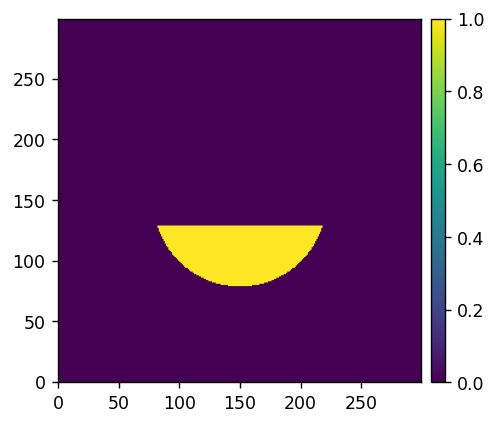

1


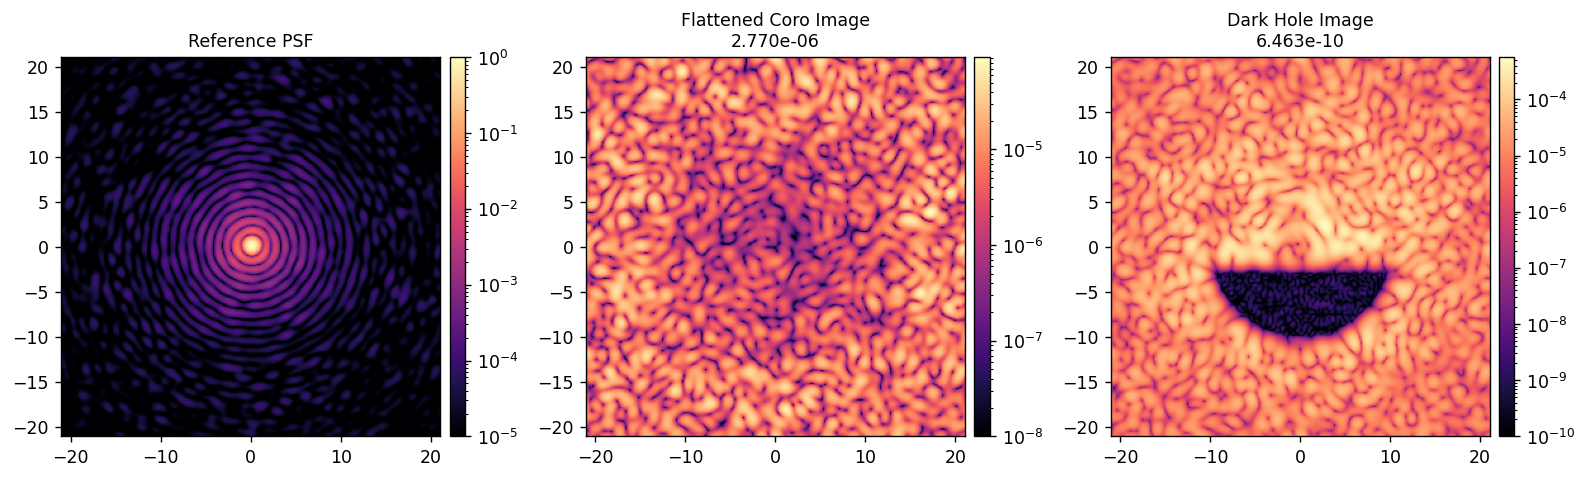

In [6]:
reload(esc)
M = esc.single(
    dm_ref=dm_flat,
)
M.wfes = wfes
M.npsf = 300

M.use_vortex = False
ref_psf = M.snap()
M.Imax_ref = xp.max(ref_psf)

M.use_vortex = True
coro_im_flat = M.snap()

M.set_dm(dh_command, channel=3)
coro_im_dh = M.snap()

iwa = 3
owa = 10
coro_mask = utils.create_annular_focal_plane_mask(
    M.npsf,
    M.camsci_pxscl_lamDc,
    irad=iwa, 
    orad=owa,
    edge=iwa,
    rotation=90,
)
imshow([coro_mask])

contrast_flat = utils.mean(coro_im_flat, coro_mask)
contrast_dh = utils.mean(coro_im_dh, coro_mask)

imshow(
    [ref_psf/M.Imax_ref, coro_im_flat, coro_im_dh],
    # [ref_psf/M.Imax_ref, coro_im_0*coro_mask, coro_im_flat*coro_mask],
    titles=[f'Reference PSF', 
            f'Flattened Coro Image\n{contrast_flat:.3e}', 
            f'Dark Hole Image\n{contrast_dh:.3e}'],
    norms=[LogNorm(vmin=1e-5), LogNorm(vmin=1e-8), LogNorm(vmin=1e-10)],
    pxscls=[M.camsci_pxscl_lamDc]*3,
    cmaps=['magma']*3,
    wspace=0.3,
)

In [5]:
def snap_bb(M, waves):
    bb_im = 0.0
    for wave in waves:
        M.wavelength = wave
        mono_im = M.snap()
        bb_im += mono_im
    return bb_im

[6.33750e-07 6.41875e-07 6.50000e-07 6.58125e-07 6.66250e-07] m
1


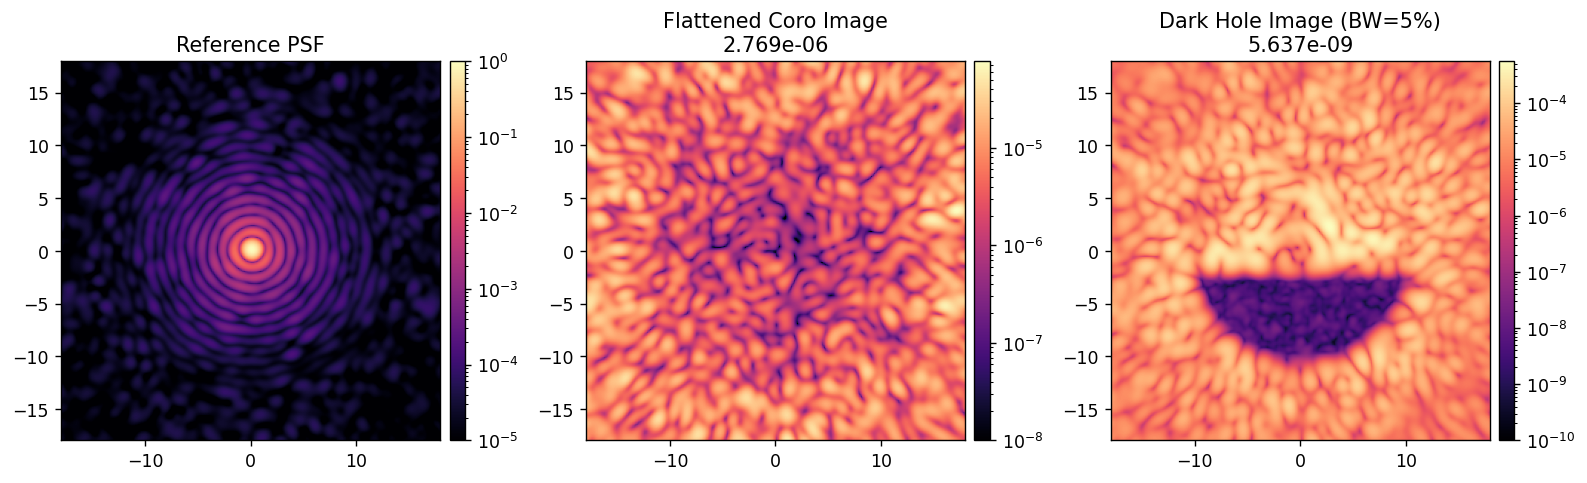

In [ ]:
bw = 0.05
waves = np.linspace((1-bw/2)*M.wavelength_c, (1+bw/2)*M.wavelength_c, 5)
print(waves)

M.reset_dm()
M.use_vortex = False
ref_psf = snap_bb(M, waves)
Imax_ref = np.max(ref_psf)

M.use_vortex = True
coro_im_flat = snap_bb(M, waves) /Imax_ref

M.set_dm(dh_command, channel=3)
coro_im_dh = snap_bb(M, waves) /Imax_ref

contrast_flat = utils.mean(coro_im_flat, coro_mask)
contrast_dh = utils.mean(coro_im_dh, coro_mask)

imshow(
    [ref_psf/Imax_ref, coro_im_flat, coro_im_dh],
    # [ref_psf/M.Imax_ref, coro_im_0*coro_mask, coro_im_flat*coro_mask],
    titles=[f'Reference PSF', 
            f'Flattened Coro Image\n{contrast_flat:.3e}', 
            f'Dark Hole Image (BW={bw*100:.0f}%)\n{contrast_dh:.3e}'],
    norms=[LogNorm(vmin=1e-5), LogNorm(vmin=1e-8), LogNorm(vmin=1e-10)],
    pxscls=[M.camsci_pxscl_lamDc]*3,
    cmaps=['magma']*3,
    wspace=0.3,
)

In [15]:
tilt = 100*u.mas

x_field_bias = 1.100000000000000E-001
y_field_bias = 0
x_field_with_tilt = x_field_bias + tilt.to_value(u.degree)
y_field_with_tilt = y_field_bias + tilt.to_value(u.degree)
print(x_field_bias)

print(x_field_with_tilt)
print(y_field_with_tilt)

0.11
0.11002777777777778
2.7777777777777782e-05


# Expected jitter/pointing error is 40mas before M4, 10mas bewteen M4 and FSM, and then 5mas for the rest.

# Perform an initial propagation to compute a reference PSF that is used to normalize the coronagraphic images. 

In [4]:
start_row = 22
end_row = 128 - 22

surf_nums = np.loadtxt(
    esc_fresnel_path/'esc_ray_on_axis.txt', 
    skiprows=start_row, 
    max_rows=end_row, 
    usecols=0, 
    encoding="utf-16", 
    dtype=int,
)

xc_on_axis = np.loadtxt(esc_fresnel_path/'esc_ray_on_axis.txt', skiprows=start_row, max_rows=end_row, usecols=1, encoding="utf-16",)
yc_on_axis = np.loadtxt(esc_fresnel_path/'esc_ray_on_axis.txt', skiprows=start_row, max_rows=end_row, usecols=2, encoding="utf-16",)

xc_off_axis_x = np.loadtxt(esc_fresnel_path/'esc_ray_off_axis_x_100mas.txt', skiprows=start_row, max_rows=end_row, usecols=1, encoding="utf-16",)
yc_off_axis_x = np.loadtxt(esc_fresnel_path/'esc_ray_off_axis_x_100mas.txt', skiprows=start_row, max_rows=end_row, usecols=2, encoding="utf-16",)

xc_off_axis_y = np.loadtxt(esc_fresnel_path/'esc_ray_off_axis_y_100mas.txt', skiprows=start_row, max_rows=end_row, usecols=1, encoding="utf-16",)
yc_off_axis_y = np.loadtxt(esc_fresnel_path/'esc_ray_off_axis_y_100mas.txt', skiprows=start_row, max_rows=end_row, usecols=2, encoding="utf-16",)



In [5]:
reload(esc_optics)

seed = 1234
optic_keys = list(esc_optics.zemax_inds.keys())
beamwalk_matrices = {}
for i in range(len(optic_keys)):
    surf_num = esc_optics.zemax_inds[optic_keys[i]]
    surf_ind = np.where(surf_num==surf_nums)[0][0]
    print(optic_keys[i])
    print(surf_num, surf_ind)

    M_bw = np.array([
        [xc_off_axis_x[surf_ind] - xc_on_axis[surf_ind], xc_off_axis_y[surf_ind] - xc_on_axis[surf_ind]],
        [yc_off_axis_x[surf_ind] - yc_on_axis[surf_ind], yc_off_axis_y[surf_ind] - yc_on_axis[surf_ind]]
    ]) * u.mm/ (100*u.mas)
    print(M_bw)

    beamwalk_matrices.update({optic_keys[i]: M_bw})


m1
4 3
[[-5.79800001e-07 -1.00000079e-10]
 [ 0.00000000e+00 -5.80000001e-07]] mm / mas
m2
5 4
[[ 3.63267000e-05 -1.03900000e-07]
 [ 2.20000004e-09  3.65406000e-05]] mm / mas
m3
6 5
[[ 3.920100e-04 -1.548200e-06]
 [-2.643000e-07  3.928213e-04]] mm / mas
m4
9 8
[[-2.44680e-07  6.24770e-07]
 [ 5.66590e-07  3.46977e-06]] mm / mas
wcc_fp
12 11
[[-4.80732370e-04 -7.25330000e-06]
 [-7.26935360e-06 -4.87234212e-04]] mm / mas
oap1
21 20
[[-6.6755237e-04  1.6391500e-06]
 [ 1.6110000e-06 -6.6342110e-04]] mm / mas
fm1
23 22
[[-4.8935312e-04  1.1368300e-06]
 [ 1.1142000e-06 -5.1517780e-04]] mm / mas
pupil_mask
27 26
[[-2.85240421e-07 -9.36825043e-06]
 [ 7.71833134e-06  2.85781731e-07]] mm / mas
oap2
30 29
[[ 4.89050000e-07 -6.33778400e-05]
 [ 6.56712093e-05 -4.99861941e-07]] mm / mas
ifp1
32 31
[[ 2.77920900e-07 -9.88472321e-05]
 [ 9.52987251e-05 -2.78383590e-07]] mm / mas
oap3
35 34
[[ 1.02610000e-07 -1.17423790e-04]
 [ 1.17069335e-04 -1.15898646e-07]] mm / mas
fsm
38 37
[[-3.37766956e-07  3.65853

1


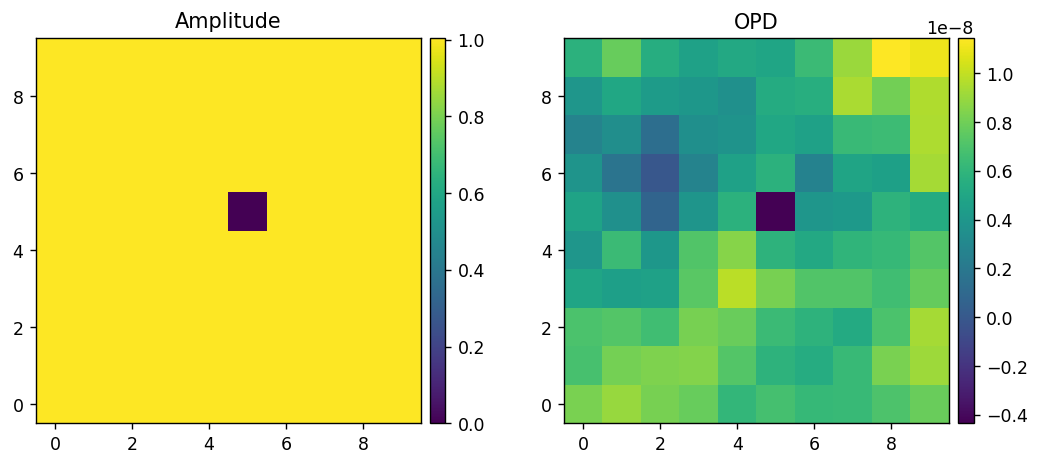

In [57]:
pointing = np.array([-10, -10])*u.mas

optic = 'oap5'

amp = copy.copy(wfes[optic].amplitude)
opd = copy.copy(wfes[optic].opd)
pxscl = wfes[optic].pixelscale
Mbw = beamwalk_matrices[optic]

shift = Mbw.dot(pointing)
shift_pix = shift.to_value(u.mm) / pxscl.to_value(u.mm/u.pix)

shifted_amp = copy.copy( xcipy.ndimage.shift( amp, (shift_pix[0], shift_pix[1])) )
shifted_opd = copy.copy( xcipy.ndimage.shift( opd, (shift_pix[0], shift_pix[1])) )

shifted_wfe = poppy.ArrayOpticalElement(
    opd=shifted_opd, 
    transmission=shifted_amp, 
    pixelscale=pxscl,
)

amp_diff = wfes[optic].amplitude - shifted_wfe.amplitude
opd_diff = wfes[optic].opd - shifted_wfe.opd

# imshow(
#     [wfes[optic].amplitude, shifted_wfe.amplitude, amp_diff,
#      wfes[optic].opd, shifted_wfe.opd, opd_diff],
#     titles=['Original Amplitude Map', 'Shifted Amplitude Map', 'Amplitude Difference',
#             'Original OPD Map', 'Shifted OPD Map', 'OPD Difference'],
#     npix=[None, None, 100, None, None, 100],
#     # norms=[CenteredNorm(vcenter=1), CenteredNorm(vcenter=1), CenteredNorm(vcenter=0)],
#     # norms=[Normalize(vmin=0.975, vmax=1.025)]*2 + [CenteredNorm(0)] + [CenteredNorm(0, 5e-8)]*2 + [CenteredNorm(0)],
#     # cmaps=['plasma']*3 + ['viridis']*3,
#     figsize=(15,12),
#     Nrows=2, Ncols=3,
#     wspace=0.3,
#     hspace=-0.3,
# )

imshow(
    [amp, opd],
    titles=['Amplitude', 'OPD'],
    npix=[10]*2,
)



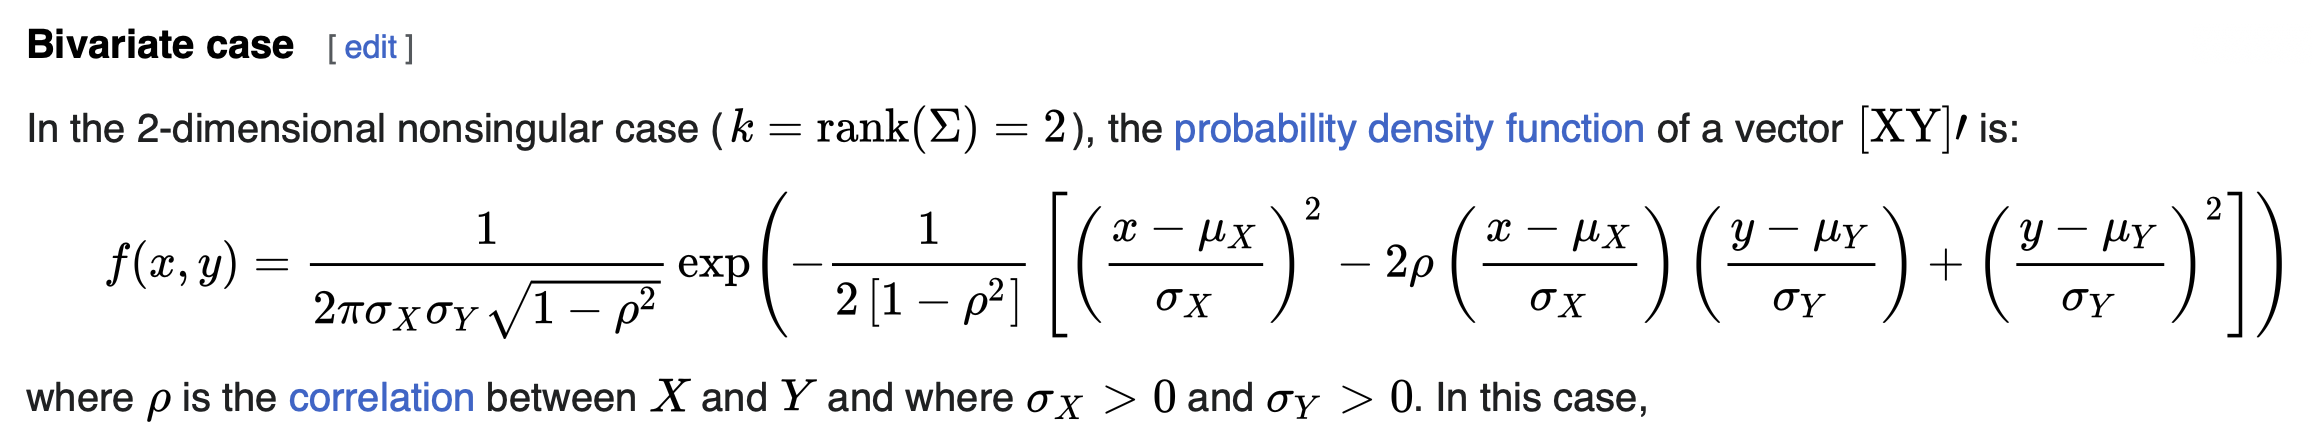


3600
(3600, 2)
1


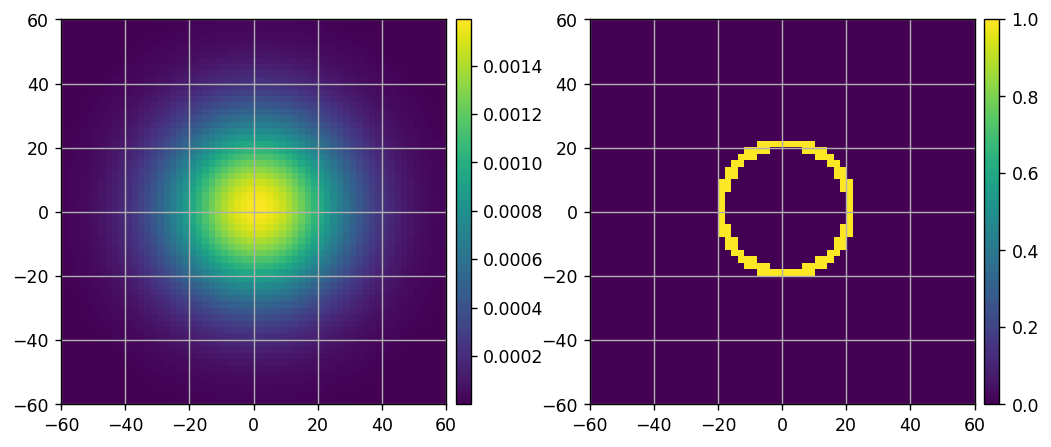

array(0.99456354)

In [8]:
jitter = 20*u.mas
pointing_sampling = jitter/10
Np = int(np.round( (6*jitter / pointing_sampling).decompose().value))
Nsamples = Np**2
print(Nsamples)

yc, xc = (xp.indices((Np, Np)) - Np//2)* pointing_sampling.to_value(u.mas)
rc = xp.sqrt(xc**2 + yc**2)
pdf_std = ( jitter.value-1.5 < rc ) * ( rc < jitter.value+2 )
pointing_samples = ensure_np_array ( xp.array([xc.flatten(), yc.flatten()]).T ) * u.mas
print(pointing_samples.shape)

amp = pointing_sampling.to_value(u.mas)**2 * 1/(2*xp.pi*jitter.to_value(u.mas)**2)
pointing_pdf = amp * xp.exp( -1/2 * ( (xc/jitter.to_value(u.mas))**2 + (yc/jitter.to_value(u.mas))**2 ) ) 
imshow(
    [pointing_pdf, pdf_std], 
    pxscls=2*[pointing_sampling.value], 
    grids=[1, 1],
)

xp.sum(pointing_pdf)

0


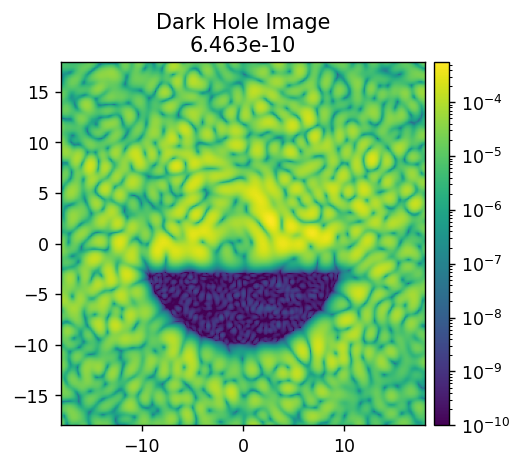

In [ ]:
M.use_vortex = True
M.wfes = wfes
M.reset_dm()
M.set_dm(dh_command)
nominal_dh = M.snap()

contrast_dh = utils.mean(nominal_dh, coro_mask)

imshow(
    [nominal_dh],
    titles=[f'Dark Hole Image\n{contrast_dh:.3e}'],
    norms=[LogNorm(1e-10)],
    pxscls=[M.camsci_pxscl_lamDc],
    # npix=[100]
)

In [12]:
import time
import copy

quiet = 1
plot = 0
plot_all_wfes = 0

N_wfe_optics = len(wfes)
wfe_keys = list(wfes.keys())

shifts = []
total_im = 0.0

start = time.time()
for i in np.arange(Nsamples):
    # if i>10: break
    pointing = pointing_samples[i]
    amp = pointing_pdf.flatten()[i]
    if not quiet: print(i, pointing, amp)

    wfes_with_beamwalk = {}
    for j in range(N_wfe_optics): 
        # This for-loop shifts the WFE of each optics by the amount computed from the given pointing error 
        optic = wfe_keys[j]
        pxscl = wfes[optic].pixelscale
        Mbw = beamwalk_matrices[optic]
        if j<=3:
            eff_pointing = pointing
        elif 3 < j & j <= 8:
            eff_pointing = pointing/4 # reduce pointing error by 4 between M4 and FSM to get the effective pointing
        elif 8 < j :
            eff_pointing = pointing/10 # reduce pointing error by 8 after FSM to get the effective pointing
        
        shift = Mbw.dot(eff_pointing)
        shift_pix = shift.to_value(u.mm) / pxscl.to_value(u.mm/u.pix)
        if not quiet:
            print('\t', optic)
            print('\t', pxscl)
            print('\t', shift)
            print('\t', shift_pix)

        shifted_opd = copy.copy( xcipy.ndimage.shift( wfes[optic].opd, (shift_pix[0], shift_pix[1])) )
        shifted_amp = copy.copy( xcipy.ndimage.shift( wfes[optic].amplitude, (shift_pix[0], shift_pix[1])) )

        shifted_wfe = poppy.ArrayOpticalElement(
            opd=shifted_opd, 
            transmission=shifted_amp, 
            pixelscale=pxscl,
        )

        wfes_with_beamwalk.update({ 
            optic:shifted_wfe,
        })

        if plot_all_wfes: 
            amp_diff = wfes[optic].amplitude - wfes_with_beamwalk[optic].amplitude
            opd_diff = wfes[optic].opd - wfes_with_beamwalk[optic].opd
            imshow(
                [wfes[optic].amplitude, wfes_with_beamwalk[optic].amplitude, amp_diff], 
                titles=[f'{optic} Amplitude Error', f'Shifted {optic} Amplitude Error', 'Difference'],
                npix=[128]*3,
            )
            imshow(
                [wfes[optic].opd, wfes_with_beamwalk[optic].opd, opd_diff], 
                titles=[f'{optic} OPD Error', f'Shifted {optic} OPD Error', 'Difference'],
                npix=[128]*3,
            )

    M.wfes = wfes_with_beamwalk
    im = M.snap()
    contrast = utils.mean(im, coro_mask)
    total_im += amp * im

    if plot: 
        print(f"\tImage {i+1:d}/{Nsamples:d} computed in {time.time()-start:.3f}s")
        optic = 'oap9'
        imshow(
            [wfes[optic].amplitude, wfes_with_beamwalk[optic].amplitude, wfes[optic].amplitude-wfes_with_beamwalk[optic].amplitude],
            npix=[100]*3,
        )
        imshow(
            [wfes[optic].opd, wfes_with_beamwalk[optic].opd, wfes[optic].opd-wfes_with_beamwalk[optic].opd],
            npix=[100]*3, 
        )
        imshow(
            [im], 
            titles=[f'({pointing[0].value:.2f}, {pointing[1].value:.2f})\nContrast = {contrast:.3e}'], 
            norms=[LogNorm(1e-10)],
        )
        clear_output(wait=True)
    else:
        print(f"\tImage {i+1:d}/{Nsamples:d} computed in {time.time()-start:.3f}s", end='')
        print("\r", end="")



        

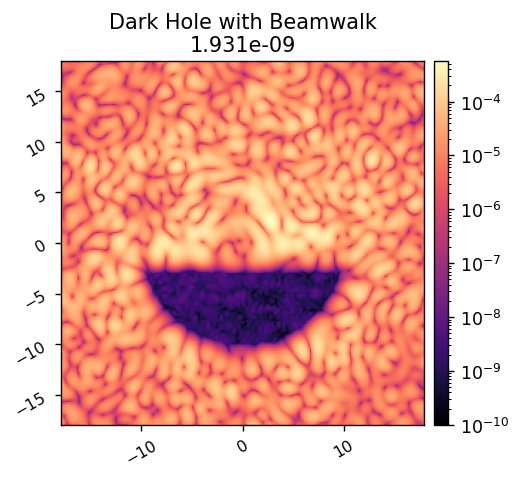

In [ ]:
contrast_with_beamwalk = utils.mean(total_im, coro_mask)

imshow1(
    total_im,
    f'Dark Hole with Beamwalk\n{contrast_with_beamwalk:.3e}',
    lognorm=1,
    pxscl=M.camsci_pxscl_lamDc,
    vmin=1e-10, 
)

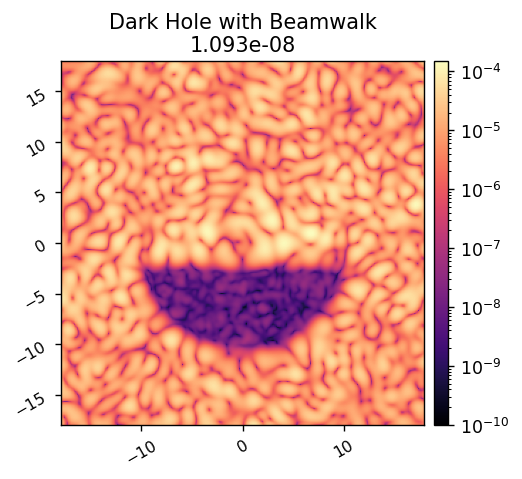

In [ ]:
contrast_with_beamwalk = utils.mean(total_im, coro_mask)

imshow1(
    total_im,
    f'Dark Hole with Beamwalk\n{contrast_with_beamwalk:.3e}',
    lognorm=1,
    pxscl=M.camsci_pxscl_lamDc,
    vmin=1e-10, 
)

In [14]:
1.93e-9 - 6.46e-10

1.2840000000000001e-09

In [18]:
1.09e-8 - 9.95e-9

9.500000000000002e-10